In [1]:
# 03_parameterized_gates.py
"""
FlagQuantum 入门教程 - 第 3 课：参数化门与梯度
目标：理解参数化门如何与 PyTorch 自动求导集成

核心概念：
1. 参数化门：RX(θ), RY(θ), RZ(θ), Phase(θ), U2(φ,λ), U3(θ,φ,λ)
2. 参数作为 torch.nn.Parameter
3. 计算梯度：∂⟨Z⟩/∂θ
4. 梯度下降优化
"""

import math

import matplotlib.pyplot as plt
import numpy as np
import torch

import flagquantum as fq


def tutorial_01_single_parameter_gate():
    """单参数门：RY(θ)"""
    print("=" * 60)
    print("3.1 单参数门 RY(θ)")
    print("=" * 60)

    # 创建可训练参数
    theta = torch.nn.Parameter(torch.tensor([0.5]))

    print(f"参数 θ = {theta.item():.4f} rad")
    print(f"需要梯度: {theta.requires_grad}")

    # 创建量子设备
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=1, device="cpu")

    # 应用 RY 门
    fq.RY(wires=[0])(qdev, params=theta)

    # 查看状态
    states = torch.view_as_complex(qdev.states)
    amp_0 = states[0][0]
    amp_1 = states[0][1]

    print(f"\nRY({theta.item():.4f})|0⟩ = {states.flatten()}")
    print(f"  |0⟩ 振幅: {amp_0:.4f}")
    print(f"  |1⟩ 振幅: {amp_1:.4f}")

    # 理论值验证
    cos_half = math.cos(theta.item() / 2)
    sin_half = math.sin(theta.item() / 2)
    print("\n理论值:")
    print(f"  cos(θ/2) = {cos_half:.4f}")
    print(f"  sin(θ/2) = {sin_half:.4f}")

    # 测量 Z 期望值
    exp_z = fq.measure_allZ(qdev)
    exp_z_scalar = exp_z.item()
    print(f"\n⟨Z⟩ = {exp_z_scalar:.4f}")
    print(f"  理论: ⟨Z⟩ = cos(θ) = {math.cos(theta.item()):.4f}")

In [2]:
tutorial_01_single_parameter_gate()

3.1 单参数门 RY(θ)
参数 θ = 0.5000 rad
需要梯度: True

RY(0.5000)|0⟩ = tensor([0.9689+0.j, 0.2474+0.j], grad_fn=<ViewBackward0>)
  |0⟩ 振幅: 0.9689+0.0000j
  |1⟩ 振幅: 0.2474+0.0000j

理论值:
  cos(θ/2) = 0.9689
  sin(θ/2) = 0.2474

⟨Z⟩ = 0.8776
  理论: ⟨Z⟩ = cos(θ) = 0.8776


In [3]:
def tutorial_02_gradient_calculation():
    """计算梯度：∂⟨Z⟩/∂θ"""
    print("\n" + "=" * 60)
    print("3.2 计算梯度 ∂⟨Z⟩/∂θ")
    print("=" * 60)

    # 确保参数需要梯度
    theta = torch.tensor([0.5], requires_grad=True)

    print(f"初始 θ = {theta.item():.4f} rad")
    print(f"requires_grad: {theta.requires_grad}")

    # 前向传播
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=1, device="cpu")
    # fq.RY(wires=[0], init_params=theta)(qdev) #无梯度
    fq.RY(wires=[0])(qdev, params=theta) # 有梯度

    # 测量
    exp_z = fq.measure_allZ(qdev)

    print(f"exp_z 类型: {type(exp_z)}")
    print(f"exp_z requires_grad: {exp_z.requires_grad}")
    print(f"exp_z: {exp_z}")

    # 确保 exp_z 是标量并需要梯度
    loss = exp_z.sum()  # 确保是标量
    print(f"loss requires_grad: {loss.requires_grad}")

    # 反向传播
    loss.backward()

    print("\n检查计算图:")
    print(f"  theta 是否在计算图中: {theta.grad is not None}")
    print(f"  loss 的 grad_fn: {loss.grad_fn}")

    # 检查梯度
    if theta.grad is not None:
        print(f"\n梯度 ∂Loss/∂θ = {theta.grad.item():.4f}")

        # 理论梯度
        theoretical_grad = -math.sin(theta.item())
        print(f"理论梯度 d⟨Z⟩/dθ = -sin(θ) = {theoretical_grad:.4f}")
    else:
        print("\n警告: theta.grad 为 None，梯度未计算")
        print("可能原因:")
        print("  1. fq.RY 没有正确记录梯度")
        print("  2. fq.measure_allZ 返回的张量 detached 了")
        print("  3. 参数没有正确连接到计算图")

In [4]:
tutorial_02_gradient_calculation()


3.2 计算梯度 ∂⟨Z⟩/∂θ
初始 θ = 0.5000 rad
requires_grad: True
exp_z 类型: <class 'torch.Tensor'>
exp_z requires_grad: True
exp_z: tensor([[0.8776]], grad_fn=<UnsafeViewBackward0>)
loss requires_grad: True

检查计算图:
  theta 是否在计算图中: True
  loss 的 grad_fn: <SumBackward0 object at 0x000002A36F848B50>

梯度 ∂Loss/∂θ = -0.4794
理论梯度 d⟨Z⟩/dθ = -sin(θ) = -0.4794


In [12]:
"""
Tutorial 03: Gradient Descent Optimization

This tutorial demonstrates gradient-based optimization of quantum circuits
using FlagQuantum's automatic differentiation capabilities.
"""


def tutorial_03_gradient_descent_optimization():

    # 初始化
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=1, device="cpu", invertible=True)
    rx_gate = fq.RX(wires=[0], trainable=True)
    rx_gate(qdev)  # Apply to device

    # 用 InvertibleUnitary 包装（用于 invertible 模式）
    if qdev.invertible:
        base_mod = [rx_gate]
        mod = fq.InvertibleUnitary(base_mod)
        mod.train()
    else:
        mod = rx_gate

    # 查看初始状态
    print(f"初始 θ = {rx_gate.params.item():.4f}")
    print("初始 ⟨Z⟩ = ?")

    # 优化
    optimizer = torch.optim.Adam([rx_gate.params], lr=0.1)
    history = []

    for step in range(200):
        optimizer.zero_grad()
        qdev.reset_states()
        mod(qdev)
        loss = fq.measure_allZ(qdev).sum()
        loss.backward()
        optimizer.step()

        history.append({
            'step': step,
            'theta': rx_gate.params.item(),
            'exp_z': loss.item()
        })

        if step % 50 == 0:
            print(f"Step {step}: θ={rx_gate.params.item():.4f}, ⟨Z⟩={loss.item():.4f}")

    # 绘图
    steps = [h['step'] for h in history]
    thetas = [h['theta'] for h in history]
    exp_zs = [h['exp_z'] for h in history]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(steps, np.abs(thetas), 'b-')
    plt.axhline(y=math.pi, color='r', linestyle='--', label='π')
    plt.xlabel('Step')
    plt.ylabel('θ (rad)')
    plt.title('Parameter Convergence')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(steps, exp_zs, 'g-')
    plt.axhline(y=-1, color='r', linestyle='--', label='-1')
    plt.xlabel('Step')
    plt.ylabel('⟨Z⟩')
    plt.title('Expectation Convergence')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n最终: θ={rx_gate.params.item():.4f}, ⟨Z⟩={history[-1]['exp_z']:.4f}")
    print(f"理论最优: θ=π={math.pi:.4f}, ⟨Z⟩=-1")

初始 θ = -0.0807
初始 ⟨Z⟩ = ?
Step 0: θ=-0.1807, ⟨Z⟩=0.9967
Step 50: θ=-3.2738, ⟨Z⟩=-0.9869
Step 100: θ=-3.1378, ⟨Z⟩=-1.0000
Step 150: θ=-3.1405, ⟨Z⟩=-1.0000


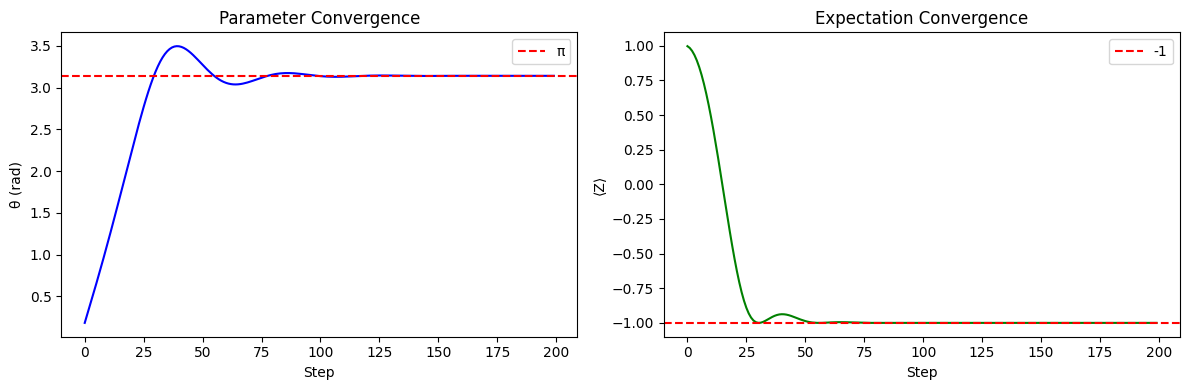


最终: θ=-3.1417, ⟨Z⟩=-1.0000
理论最优: θ=π=3.1416, ⟨Z⟩=-1


In [13]:
tutorial_03_gradient_descent_optimization()

In [5]:



def test_inv_cpu(verbose=False):
    """
    invertible gradient test on CPU (single process)
    """
    nq = 3
    world_sz = 1

    # 创建非 invertible 设备
    qdev = fq.DistributedQuantumDevice(
        nq,
        bsz=1,
        device="cpu",
        world_sz=world_sz,
        invertible=False,
    )

    # 创建 invertible 设备
    qdev_i = fq.DistributedQuantumDevice(
        nq,
        bsz=1,
        device="cpu",
        world_sz=world_sz,
        invertible=True,
    )

    # test registration
    fq.ops.register_gate("id", torch.eye(2, dtype=torch.cfloat))

    def fun(qdev, inp):
        func_list = [
            {"func": "ry", "wires": [0], "input_idx": [0]},
            {"func": "ry", "wires": [1], "input_idx": [1]},
            {"func": "ry", "wires": [2], "input_idx": [2]},
        ]
        enc = fq.GeneralEncoder(func_list)
        base_mod = (
            [enc]
            + [fq.CX(wires=[i, (i + 1) % nq]) for i in range(qdev.n_wires)]
            + [fq.ops.registry.ID(wires=[1])]
        )
        if qdev.invertible:
            mod = fq.InvertibleUnitary(base_mod)
            mod.train()
            mod(qdev, inp)
        else:
            enc(qdev, inp)
            if verbose:
                print(f"  after enc: {qdev._states}")
            for m_ in base_mod[1:]:
                m_.train()
                m_(qdev)
                if verbose:
                    print(f"  after {type(m_).__name__}: {qdev._states}")

        # 修正：measure_allZ 的正确参数顺序
        # measure_allZ(q_device, shots=0, postselect_cond=None, training=False)
        a,b = qdev.noncanonical_states
        print("a:", a)
        print("qdev.noncanonical_states:", qdev.noncanonical_states)
        meas_approx = fq.measure_allZ(qdev, training=True)
        return meas_approx

    print("=" * 60)
    print("Testing invertible=True on CPU")
    print("=" * 60)

    # ========== 测试 invertible=True ==========
    print("\n--- Testing invertible=True ---")
    x_i = torch.nn.Parameter(
        torch.tensor([[torch.pi / 3, -torch.pi / 3, torch.pi / 6]], dtype=torch.float32, requires_grad=True)
    )

    out_i = fun(qdev_i, x_i)
    print(f"Output (invertible): {out_i}")

    loss_i = out_i.abs().sum()
    loss_i.backward()

    print(f"x_i.grad: {x_i.grad}")
    if x_i.grad is not None:
        x_i_grad = x_i.grad.clone()
    else:
        x_i_grad = None
        print("Warning: x_i.grad is None!")

    # ========== 测试 invertible=False ==========
    print("\n--- Testing invertible=False ---")
    x = torch.nn.Parameter(
        torch.tensor([[torch.pi / 3, -torch.pi / 3, torch.pi / 6]], dtype=torch.float32, requires_grad=True)
    )

    out = fun(qdev, x)
    print(f"Output: {out}")

    loss = out.abs().sum()
    loss.backward()

    print(f"x.grad: {x.grad}")
    if x.grad is not None:
        x_grad = x.grad.clone()
    else:
        x_grad = None
        print("Warning: x.grad is None!")

    # ========== 对比结果 ==========
    print("\n" + "=" * 60)
    print("Gradient Comparison")
    print("=" * 60)

    if x_i_grad is not None and x_grad is not None:
        print(f"invertible=True  grad: {x_i_grad}")
        print(f"invertible=False grad: {x_grad}")

        if torch.allclose(x_i_grad, x_grad, atol=1e-5, rtol=1e-5):
            print("\n✅ PASSED: Gradients match!")
        else:
            diff = torch.abs(x_i_grad - x_grad)
            print(f"\n❌ FAILED: Gradient difference: {diff}")
    elif x_i_grad is None and x_grad is None:
        print("\n❌ Both gradients are None")
    elif x_i_grad is None:
        print("\n❌ invertible=True gradient is None")
    else:
        print("\n❌ invertible=False gradient is None")

    return x_i_grad, x_grad


def test_single_rx_invertible():
    """测试单个 RX 门的 invertible 模式"""
    print("\n" + "=" * 60)
    print("Testing single RX gate with invertible=True")
    print("=" * 60)

    # 创建 invertible 设备
    qdev = fq.DistributedQuantumDevice(
        n_wires=1,
        bsz=1,
        device="cpu",
        invertible=True,
    )

    # 创建可训练的 RX 门
    rx_gate = fq.RX(wires=[0], trainable=True)
    rx_gate(qdev)

    print(f"Initial θ: {rx_gate.params.item():.4f}")

    # 前向传播
    qdev.reset_states()
    rx_gate(qdev)
    exp_z = fq.measure_allZ(qdev, shots=0, training=True)
    loss = exp_z.sum()

    # 反向传播
    loss.backward()

    print(f"θ.grad: {rx_gate.params.grad}")
    print(f"Loss: {loss.item():.6f}")

    if rx_gate.params.grad is not None:
        print("✅ Gradient exists!")
        return True
    else:
        print("❌ Gradient is None!")
        return False


if __name__ == "__main__":
    # 测试单个 RX 门
    test_single_rx_invertible()

    # 测试完整的 invertible 功能
    test_inv_cpu(verbose=False)


Testing single RX gate with invertible=True
Initial θ: 0.2593
θ.grad: tensor([[0.]])
Loss: 0.966570
✅ Gradient exists!
Testing invertible=True on CPU

--- Testing invertible=True ---
a: tensor([[[[[ 0.7244,  0.0000],
           [-0.1121,  0.0000]],

          [[-0.2415,  0.0000],
           [ 0.1121,  0.0000]]],


         [[[-0.0647,  0.0000],
           [ 0.4183,  0.0000]],

          [[ 0.1941,  0.0000],
           [-0.4183,  0.0000]]]]], grad_fn=<InvertiblePostUnitaryStepBackward>)
qdev.noncanonical_states: (tensor([[[[[ 0.7244,  0.0000],
           [-0.1121,  0.0000]],

          [[-0.2415,  0.0000],
           [ 0.1121,  0.0000]]],


         [[[-0.0647,  0.0000],
           [ 0.4183,  0.0000]],

          [[ 0.1941,  0.0000],
           [-0.4183,  0.0000]]]]], grad_fn=<InvertiblePostUnitaryStepBackward>), tensor([[ 2,  3,  1],
        [-1, -1, -1]], dtype=torch.int32))
Output (invertible): tensor([[0.4330, 0.2500, 0.2165]], grad_fn=<UnsafeViewBackward0>)
x_i.grad: tensor([[-0.8

In [14]:
def tutorial_04_multi_parameter_gates():
    """多参数门：U3(θ, φ, λ)"""
    print("\n" + "=" * 60)
    print("3.4 多参数门 U3(θ, φ, λ)")
    print("=" * 60)

    # U3 参数
    theta = math.pi / 3
    phi = 0.5
    lam = 0.3

    # 组合成 [batch, 3] 形状
    params = torch.tensor([[theta, phi, lam]])

    # params = torch.tensor([[-0.1683, -0.2484, -0.3083]], requires_grad=True)

    print("U3 参数:")
    print(f"  θ = {theta:.4f} rad")
    print(f"  φ = {phi:.4f} rad")
    print(f"  λ = {lam:.4f} rad")

    # 应用 U3 门
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=1, device="cpu")
    u3_gate = fq.U3(wires=[0])
    u3_gate(qdev,params=params)

    print(u3_gate.params)

    states = torch.view_as_complex(qdev.states)
    amp_0 = states[0][0]
    amp_1 = states[0][1]

    print(f"\nU3(θ,φ,λ)|0⟩ = {states.flatten()}")
    print(f"  |0⟩ 振幅: {amp_0:.4f}")
    print(f"  |1⟩ 振幅: {amp_1:.4f}")

    # 理论公式
    cos_half = math.cos(theta / 2)
    sin_half = math.sin(theta / 2)

    print("\n理论值:")
    print(f"  |0⟩: {cos_half:.4f}")
    print(f"  |1⟩: {sin_half:.4f} * e^{{{phi:.4f}i}} = {sin_half * math.cos(phi):.4f} + {sin_half * math.sin(phi):.4f}i")

In [15]:
tutorial_04_multi_parameter_gates()


3.4 多参数门 U3(θ, φ, λ)
U3 参数:
  θ = 1.0472 rad
  φ = 0.5000 rad
  λ = 0.3000 rad
tensor([[1.0472, 0.5000, 0.3000]])

U3(θ,φ,λ)|0⟩ = tensor([0.8660+0.0000j, 0.4388+0.2397j])
  |0⟩ 振幅: 0.8660+0.0000j
  |1⟩ 振幅: 0.4388+0.2397j

理论值:
  |0⟩: 0.8660
  |1⟩: 0.5000 * e^{0.5000i} = 0.4388 + 0.2397i


In [16]:
def tutorial_05_batch_parameters():
    """批处理参数"""
    print("\n" + "=" * 60)
    print("3.5 批处理参数")
    print("=" * 60)

    batch_size = 4
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=batch_size, device="cpu")

    # 创建批处理参数：每个样本有独立的 θ
    thetas = torch.nn.Parameter(torch.randn(batch_size, 1) * math.pi)

    print(f"批处理大小: {batch_size}")
    print(f"参数形状: {thetas.shape}")
    print("各样本的 θ:")
    for i, theta in enumerate(thetas):
        print(f"  样本 {i}: {theta.item():.4f} rad")

    # 应用批处理 RY 门
    fq.RY(wires=[0])(qdev, params=thetas)

    # 查看批处理状态
    states = torch.view_as_complex(qdev.states)
    print(f"\n批处理状态形状: {states.shape}")

    print("\n各样本的 ⟨Z⟩:")
    exp_vals = fq.measure_allZ(qdev)
    for i in range(batch_size):
        exp_z = exp_vals[i][0].item()
        print(f"  样本 {i}: ⟨Z⟩ = {exp_z:.4f} (理论: cos({thetas[i].item():.4f}) = {math.cos(thetas[i].item()):.4f})")

In [17]:
tutorial_05_batch_parameters()


3.5 批处理参数
批处理大小: 4
参数形状: torch.Size([4, 1])
各样本的 θ:
  样本 0: 0.3536 rad
  样本 1: 6.1450 rad
  样本 2: 0.5219 rad
  样本 3: -1.0502 rad

批处理状态形状: torch.Size([4, 2])

各样本的 ⟨Z⟩:
  样本 0: ⟨Z⟩ = 0.9381 (理论: cos(0.3536) = 0.9381)
  样本 1: ⟨Z⟩ = 0.9905 (理论: cos(6.1450) = 0.9905)
  样本 2: ⟨Z⟩ = 0.8669 (理论: cos(0.5219) = 0.8669)
  样本 3: ⟨Z⟩ = 0.4974 (理论: cos(-1.0502) = 0.4974)


In [18]:
def tutorial_06_multiple_parameters_gradient():
    """多参数梯度计算"""
    print("\n" + "=" * 60)
    print("3.6 多参数梯度计算")
    print("=" * 60)

    # 创建多个可训练参数
    theta1 = torch.nn.Parameter(torch.tensor([0.5]))
    theta2 = torch.nn.Parameter(torch.tensor([0.3]))

    print("初始参数:")
    print(f"  θ₁ = {theta1.item():.4f} rad")
    print(f"  θ₂ = {theta2.item():.4f} rad")

    # 前向传播：两个 RY 门
    qdev = fq.DistributedQuantumDevice(n_wires=1, bsz=1, device="cpu")
    fq.RY(wires=[0])(qdev, params=theta1)
    fq.RY(wires=[0])(qdev, params=theta2)

    # 复合旋转：RY(θ₂)∘RY(θ₁) = RY(θ₁+θ₂)
    total_theta = theta1 + theta2

    states = torch.view_as_complex(qdev.states)
    print(f"\n状态: {states.flatten()}")
    print(f"等价于单次 RY({total_theta.item():.4f})")

    # 测量
    exp_z = fq.measure_allZ(qdev)
    loss = exp_z.sum()

    # 反向传播
    loss.backward()

    print(f"\n⟨Z⟩ = {exp_z.item():.4f}")
    print(f"Loss = {loss.item():.4f}")
    print("\n梯度:")
    print(f"  ∂Loss/∂θ₁ = {theta1.grad.item():.4f}")
    print(f"  ∂Loss/∂θ₂ = {theta2.grad.item():.4f}")

    # 理论：∂⟨Z⟩/∂θ = -sin(θ₁+θ₂)，两个梯度应该相等
    theoretical_grad = -math.sin(total_theta.item())
    print("\n理论梯度:")
    print(f"  d⟨Z⟩/dθ = -sin(θ₁+θ₂) = {theoretical_grad:.4f}")
    print(f"  两个梯度应该相等: {theta1.grad.item():.4f} ≈ {theta2.grad.item():.4f}")

In [19]:
tutorial_06_multiple_parameters_gradient()


3.6 多参数梯度计算
初始参数:
  θ₁ = 0.5000 rad
  θ₂ = 0.3000 rad

状态: tensor([0.9211+0.j, 0.3894+0.j], grad_fn=<ViewBackward0>)
等价于单次 RY(0.8000)

⟨Z⟩ = 0.6967
Loss = 0.6967

梯度:
  ∂Loss/∂θ₁ = -0.7174
  ∂Loss/∂θ₂ = -0.7174

理论梯度:
  d⟨Z⟩/dθ = -sin(θ₁+θ₂) = -0.7174
  两个梯度应该相等: -0.7174 ≈ -0.7174
